## 1. Cargar los Datos

Primero cargamos el archivo JSON con los datos de especialistas.

In [21]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Cargar datos
with open('data/mental_health_specialists_cleaned.json', 'r', encoding='utf-8') as f:
    specialists = json.load(f)

print(f"Datos cargados: {len(specialists):,} especialistas")
print(f"\nTipo de datos: {type(specialists)}")
print(f"Cada especialista es un: {type(specialists[0])}")

Datos cargados: 4,291 especialistas

Tipo de datos: <class 'list'>
Cada especialista es un: <class 'dict'>


## 2. Ver la Estructura de los Datos

Veamos qué información tiene cada especialista.

In [22]:
# Ver los campos disponibles en el primer especialista
print("Campos disponibles:")
print("=" * 50)
for key in specialists[0].keys():
    print(f"  - {key}")

print(f"\nTotal de campos: {len(specialists[0].keys())}")

Campos disponibles:
  - npi
  - provider_type
  - name
  - credential
  - primary_taxonomy
  - primary_taxonomy_code
  - all_taxonomies
  - practice_location
  - mailing_address
  - identifiers
  - endpoints
  - last_updated
  - status

Total de campos: 13


## 3. Ejemplo de un Especialista

Veamos cómo se ve un especialista completo.

In [23]:
# Mostrar primer especialista de forma bonita
print("EJEMPLO DE ESPECIALISTA")
print("=" * 70)

example = specialists[0]

# Campos básicos
print(f"\nINFORMACION BASICA:")
print(f"   NPI: {example.get('npi')}")
print(f"   Nombre: {example.get('name')}")
print(f"   Tipo: {example.get('provider_type')}")
print(f"   Credencial: {example.get('credential')}")
print(f"   Estado: {example.get('status')}")

# Especialidad
print(f"\nESPECIALIDAD:")
print(f"   Primaria: {example.get('primary_taxonomy')}")
print(f"   Código: {example.get('primary_taxonomy_code')}")

# Ubicación (necesitamos parsear el JSON string)
import json
location = json.loads(example.get('practice_location', '{}'))
print(f"\nUBICACION:")
print(f"   Dirección: {location.get('address_1', 'N/A')}")
print(f"   Ciudad: {location.get('city', 'N/A')}")
print(f"   Estado: {location.get('state', 'N/A')}")
print(f"   Código Postal: {location.get('postal_code', 'N/A')}")
print(f"   Teléfono: {location.get('telephone', 'N/A')}")

print("\n" + "=" * 70)

EJEMPLO DE ESPECIALISTA

INFORMACION BASICA:
   NPI: 1417367343
   Nombre: GARY T GOSSINGER MD PA
   Tipo: Organization
   Credencial: None
   Estado: A

ESPECIALIDAD:
   Primaria: Psychiatry & Neurology, Psychiatry
   Código: 2084P0800X

UBICACION:
   Dirección: 2830 NW 41ST ST
   Ciudad: GAINESVILLE
   Estado: FL
   Código Postal: 326066667
   Teléfono: 352-371-6402



## 4. Convertir a DataFrame para Análisis

Pandas nos facilita el análisis de datos.

In [24]:
# Crear DataFrame
df = pd.DataFrame(specialists)

print(f"DataFrame creado con {len(df):,} filas y {len(df.columns)} columnas")
print(f"\nDimensiones: {df.shape}")
print(f"\nPrimeras 3 filas:")
df.head(3)

DataFrame creado con 4,291 filas y 13 columnas

Dimensiones: (4291, 13)

Primeras 3 filas:


,npi,provider_type,name,credential,primary_taxonomy,primary_taxonomy_code,all_taxonomies,practice_location,mailing_address,identifiers,endpoints,last_updated,status
0,1417367343,Organization,GARY T GOSSINGER MD PA,None,"Psychiatry & Neurology, Psychiatry",2084P0800X,"[{""code"": ""2084P0800X"", ""desc"": ""Psychiatry & ...","{""address_1"": ""2830 NW 41ST ST"", ""address_2"": ...","{""country_code"": ""US"", ""country_name"": ""United...",[],[],2014-04-30,A
1,1134520182,Organization,1 CP PLACE PLLC,None,"Psychiatry & Neurology, Neurology with Special...",2084N0402X,"[{""code"": ""2084N0402X"", ""desc"": ""Psychiatry & ...","{""address_1"": ""PO BOX 251665"", ""address_2"": nu...","{""country_code"": ""US"", ""country_name"": ""United...","[{""code"": ""05"", ""desc"": ""MEDICAID"", ""issuer"": ...",[],2016-01-15,A
2,1972171536,Organization,1 LIFE NEUROLOGY CENTER,None,"Psychiatry & Neurology, Neurology",2084N0400X,"[{""code"": ""2084N0400X"", ""desc"": ""Psychiatry & ...","{""address_1"": ""1919 WOODWARD AVE"", ""address_2""...","{""country_code"": ""US"", ""country_name"": ""United...",[],[],2021-12-28,A


## 5. Tipos de Especialistas

¿Qué tipos de especialistas tenemos?

TIPOS DE PROVEEDORES
   Individual: 2,250 (52.4%)
   Organization: 2,041 (47.6%)

Total: 4,291 especialistas


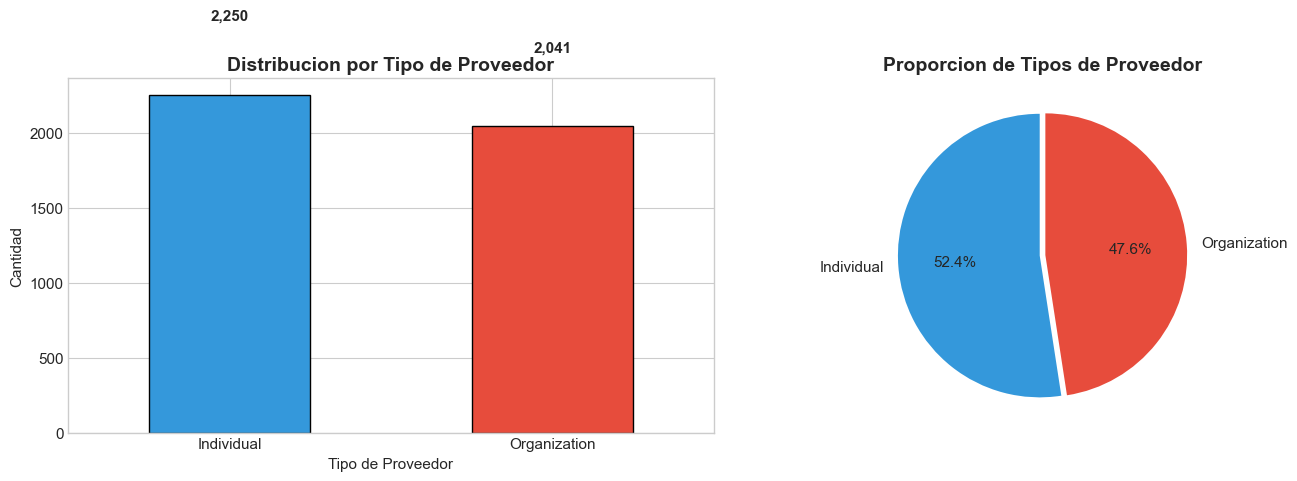

In [25]:
# Contar por tipo de proveedor
print("TIPOS DE PROVEEDORES")
print("=" * 50)
provider_types = df['provider_type'].value_counts()
for ptype, count in provider_types.items():
    percentage = (count / len(df)) * 100
    print(f"   {ptype}: {count:,} ({percentage:.1f}%)")

print(f"\nTotal: {len(df):,} especialistas")

# Visualizacion: Grafico de pastel para tipos de proveedores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras
colors = ['#3498db', '#e74c3c']
provider_types.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribucion por Tipo de Proveedor', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de Proveedor')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# Agregar etiquetas de valor
for i, (idx, val) in enumerate(provider_types.items()):
    axes[0].text(i, val + 500, f'{val:,}', ha='center', fontweight='bold')

# Grafico de pastel
axes[1].pie(provider_types, labels=provider_types.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.02, 0.02])
axes[1].set_title('Proporcion de Tipos de Proveedor', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Especialidades Más Comunes

¿Cuáles son las especialidades principales?

TOP 15 ESPECIALIDADES
 1. Psychiatry & Neurology, Neurology                               821 (19.13%)
 2. Psychiatry & Neurology, Psychiatry                              741 (17.27%)
 3. Counselor, Mental Health                                        606 (14.12%)
 4. Psychologist, Clinical                                          456 (10.63%)
 5. Psychologist                                                    385 ( 8.97%)
 6. Clinic/Center, Mental Health (Including Community Mental Health Center)    342 ( 7.97%)
 7. Psychiatry & Neurology, Neurology with Special Qualifications in Child Neurology     80 ( 1.86%)
 8. Psychologist, School                                             65 ( 1.51%)
 9. Social Worker, Clinical                                          58 ( 1.35%)
10. Community/Behavioral Health                                      55 ( 1.28%)
11. Counselor, Professional                                          36 ( 0.84%)
12. Psychologist, Clinical Child & Adolescent           

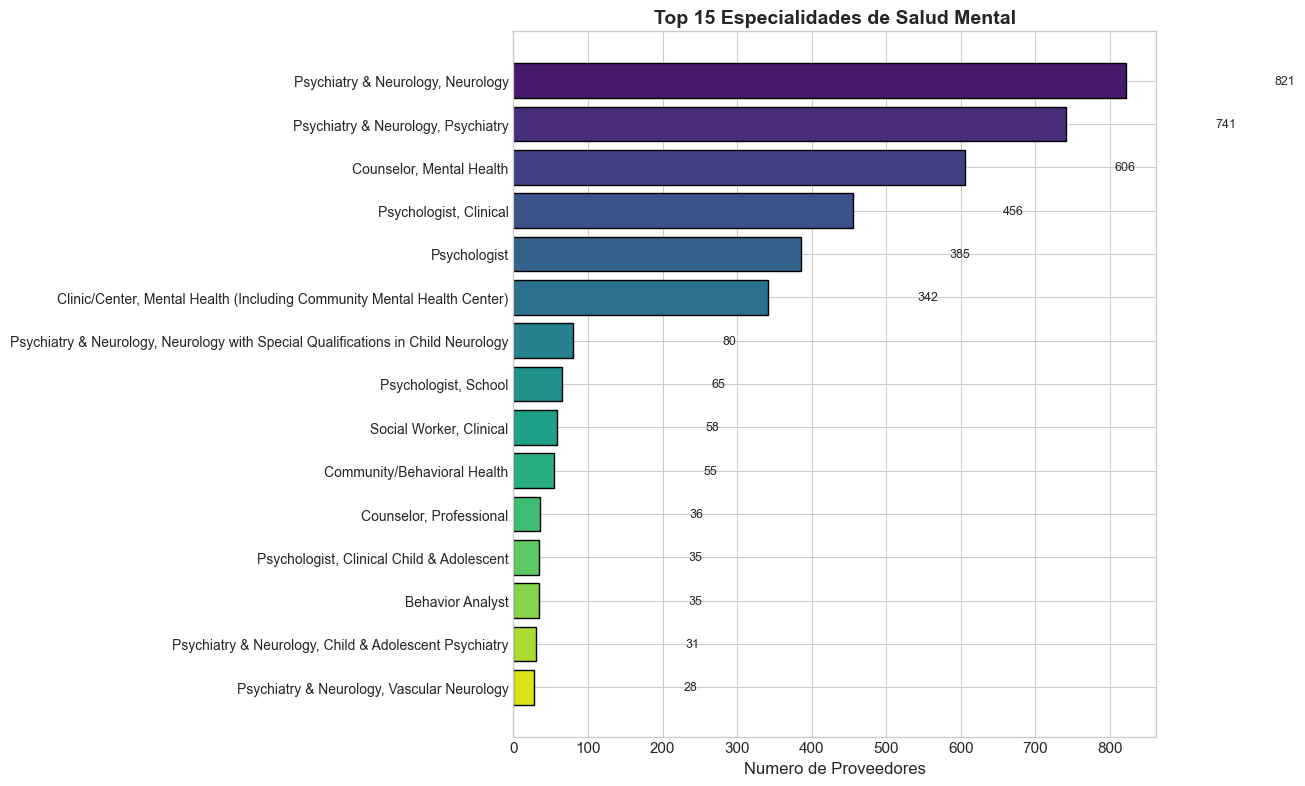

In [26]:
# Top 15 especialidades
print("TOP 15 ESPECIALIDADES")
print("=" * 70)

top_specialties = df['primary_taxonomy'].value_counts().head(15)
for i, (specialty, count) in enumerate(top_specialties.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i:2d}. {specialty:60s} {count:6,} ({percentage:5.2f}%)")

print(f"\nTotal de especialidades unicas: {df['primary_taxonomy'].nunique():,}")

# Visualizacion: Grafico de barras horizontales para especialidades
fig, ax = plt.subplots(figsize=(14, 8))

colors = sns.color_palette("viridis", len(top_specialties))
bars = ax.barh(range(len(top_specialties)), top_specialties.values, color=colors, edgecolor='black')

ax.set_yticks(range(len(top_specialties)))
ax.set_yticklabels(top_specialties.index, fontsize=10)
ax.invert_yaxis()  # Mayor arriba
ax.set_xlabel('Numero de Proveedores', fontsize=12)
ax.set_title('Top 15 Especialidades de Salud Mental', fontsize=14, fontweight='bold')

# Agregar etiquetas de valor
for i, (bar, val) in enumerate(zip(bars, top_specialties.values)):
    ax.text(val + 200, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Distribución Geográfica

¿En qué estados hay más especialistas?

TOP 15 ESTADOS CON MAS ESPECIALISTAS
 1. CA                 480 especialistas (11.19%)
 2. NY                 309 especialistas ( 7.20%)
 3. TX                 304 especialistas ( 7.08%)
 4. FL                 303 especialistas ( 7.06%)
 5. IL                 192 especialistas ( 4.47%)
 6. MI                 166 especialistas ( 3.87%)
 7. MA                 158 especialistas ( 3.68%)
 8. OH                 146 especialistas ( 3.40%)
 9. PA                 146 especialistas ( 3.40%)
10. NJ                 140 especialistas ( 3.26%)
11. MD                 136 especialistas ( 3.17%)
12. NC                 134 especialistas ( 3.12%)
13. CO                  98 especialistas ( 2.28%)
14. AZ                  93 especialistas ( 2.17%)
15. VA                  91 especialistas ( 2.12%)

Total de estados: 58


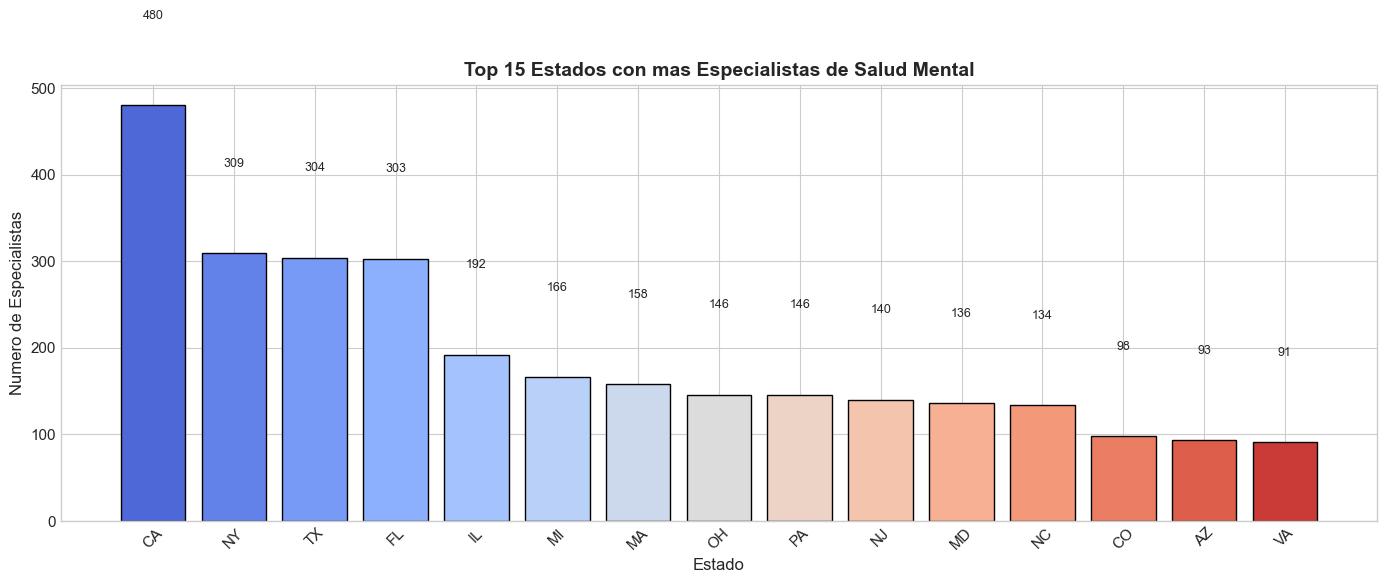

In [27]:
# Extraer estados de practice_location
def extract_state(location_str):
    """Extrae el estado del JSON de ubicacion"""
    try:
        location = json.loads(location_str) if isinstance(location_str, str) else location_str
        return location.get('state', 'Unknown')
    except:
        return 'Unknown'

df['state'] = df['practice_location'].apply(extract_state)

# Top 15 estados
print("TOP 15 ESTADOS CON MAS ESPECIALISTAS")
print("=" * 70)

top_states = df['state'].value_counts().head(15)
for i, (state, count) in enumerate(top_states.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i:2d}. {state:15s} {count:6,} especialistas ({percentage:5.2f}%)")

print(f"\nTotal de estados: {df['state'].nunique()}")

# Visualizacion: Grafico de barras para estados
fig, ax = plt.subplots(figsize=(14, 6))

colors = sns.color_palette("coolwarm", len(top_states))
bars = ax.bar(range(len(top_states)), top_states.values, color=colors, edgecolor='black')

ax.set_xticks(range(len(top_states)))
ax.set_xticklabels(top_states.index, fontsize=11, rotation=45)
ax.set_xlabel('Estado', fontsize=12)
ax.set_ylabel('Numero de Especialistas', fontsize=12)
ax.set_title('Top 15 Estados con mas Especialistas de Salud Mental', fontsize=14, fontweight='bold')

# Agregar etiquetas de valor
for i, (bar, val) in enumerate(zip(bars, top_states.values)):
    ax.text(i, val + 100, f'{val:,}', ha='center', fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

## 8. Campos Importantes para Búsqueda

Identifiquemos qué campos podemos usar para crear descripciones ricas para el sistema RAG.

COMPLETITUD DE CAMPOS IMPORTANTES
[OK] npi                      :  4,291 /  4,291 (100.00%)
[OK] name                     :  4,291 /  4,291 (100.00%)
[OK] provider_type            :  4,291 /  4,291 (100.00%)
[XX] credential               :  1,938 /  4,291 ( 45.16%)
[OK] primary_taxonomy         :  4,291 /  4,291 (100.00%)
[OK] primary_taxonomy_code    :  4,291 /  4,291 (100.00%)
[OK] all_taxonomies           :  4,291 /  4,291 (100.00%)
[OK] practice_location        :  4,291 /  4,291 (100.00%)
[OK] status                   :  4,291 /  4,291 (100.00%)

Nota: Campos con 100% completitud son ideales para busqueda.


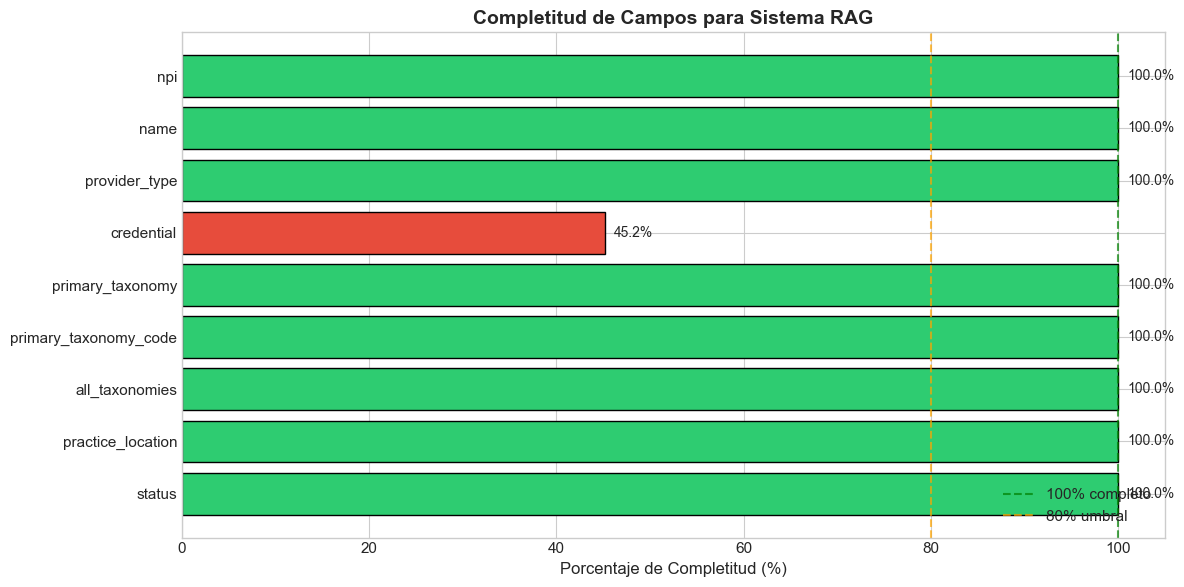

In [28]:
# Analizar completitud de campos clave
print("COMPLETITUD DE CAMPOS IMPORTANTES")
print("=" * 70)

important_fields = [
    'npi',
    'name', 
    'provider_type',
    'credential',
    'primary_taxonomy',
    'primary_taxonomy_code',
    'all_taxonomies',
    'practice_location',
    'status'
]

completeness_data = []
for field in important_fields:
    if field in df.columns:
        total = len(df)
        non_null = df[field].notna().sum()
        percentage = (non_null / total) * 100
        completeness_data.append({'field': field, 'percentage': percentage})
        
        # Indicador segun completitud
        if percentage >= 99:
            indicator = "[OK]"
        elif percentage >= 80:
            indicator = "[--]"
        else:
            indicator = "[XX]"
        
        print(f"{indicator} {field:25s}: {non_null:6,} / {total:6,} ({percentage:6.2f}%)")

print("\nNota: Campos con 100% completitud son ideales para busqueda.")

# Visualizacion: Grafico de completitud de campos
fig, ax = plt.subplots(figsize=(12, 6))

completeness_df = pd.DataFrame(completeness_data)
colors = ['#2ecc71' if p >= 99 else '#f39c12' if p >= 80 else '#e74c3c' 
          for p in completeness_df['percentage']]

bars = ax.barh(completeness_df['field'], completeness_df['percentage'], color=colors, edgecolor='black')

ax.set_xlim(0, 105)
ax.set_xlabel('Porcentaje de Completitud (%)', fontsize=12)
ax.set_title('Completitud de Campos para Sistema RAG', fontsize=14, fontweight='bold')
ax.axvline(x=100, color='green', linestyle='--', alpha=0.7, label='100% completo')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.7, label='80% umbral')

# Agregar etiquetas de valor
for i, (bar, val) in enumerate(zip(bars, completeness_df['percentage'])):
    ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=10)

ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Crear Texto Descriptivo de Ejemplo

Así es como combinaremos los campos para crear descripciones ricas para el sistema RAG.

In [29]:
def create_description(specialist):
    """
    Crea una descripción rica del especialista para búsqueda semántica.
    Combina: nombre, tipo, especialidad, ubicación.
    """
    parts = []
    
    # Nombre y credencial
    if specialist.get('name'):
        parts.append(specialist['name'])
    if specialist.get('credential'):
        parts.append(specialist['credential'])
    
    # Tipo de proveedor
    if specialist.get('provider_type'):
        parts.append(specialist['provider_type'])
    
    # Especialidad
    if specialist.get('primary_taxonomy'):
        parts.append(specialist['primary_taxonomy'])
    
    # Ubicación (ciudad y estado)
    try:
        location = json.loads(specialist.get('practice_location', '{}'))
        city = location.get('city', '')
        state = location.get('state', '')
        if city:
            parts.append(city)
        if state:
            parts.append(state)
    except:
        pass
    
    return ' '.join([p for p in parts if p])

# Ejemplo con los primeros 3 especialistas
print("EJEMPLOS DE DESCRIPCIONES PARA RAG")
print("=" * 70)

for i in range(3):
    specialist = specialists[i]
    description = create_description(specialist)
    print(f"\n{i+1}. NPI: {specialist['npi']}")
    print(f"   Descripcion: {description}")
    print(f"   Longitud: {len(description)} caracteres")

print("\nEstas descripciones se convertiran en embeddings para busqueda.")

EJEMPLOS DE DESCRIPCIONES PARA RAG

1. NPI: 1417367343
   Descripcion: GARY T GOSSINGER MD PA Organization Psychiatry & Neurology, Psychiatry GAINESVILLE FL
   Longitud: 85 caracteres

2. NPI: 1134520182
   Descripcion: 1 CP PLACE PLLC Organization Psychiatry & Neurology, Neurology with Special Qualifications in Child Neurology PLANO TX
   Longitud: 118 caracteres

3. NPI: 1972171536
   Descripcion: 1 LIFE NEUROLOGY CENTER Organization Psychiatry & Neurology, Neurology MUSCLE SHOALS AL
   Longitud: 87 caracteres

Estas descripciones se convertiran en embeddings para busqueda.


## 10. Resumen de Insights

**¿Qué aprendimos?**

1. **Datos completos**: Tenemos {len(df):,} especialistas de salud mental en USA
2. **Tipos**: Principalmente organizaciones e individuos
3. **Especialidades**: Variedad de psiquiatría, neurología, psicología
4. **Ubicación**: Distribuidos en todos los estados USA
5. **Campos útiles**: NPI, nombre, especialidad, ubicación están 100% completos

**Próximo paso:**
- Crear sistema RAG (Retrieval-Augmented Generation) usando:
  - OpenAI Embeddings (text-embedding-3-small)
  - FAISS para búsqueda vectorial rápida
  - Filtros por ubicación y especialidad

ESTADISTICAS FINALES
Total especialistas: 4,291
Especialidades unicas: 127
Estados cubiertos: 58
Organizaciones: 2,041
Individuos: 2,250

Datos listos para crear el sistema RAG.


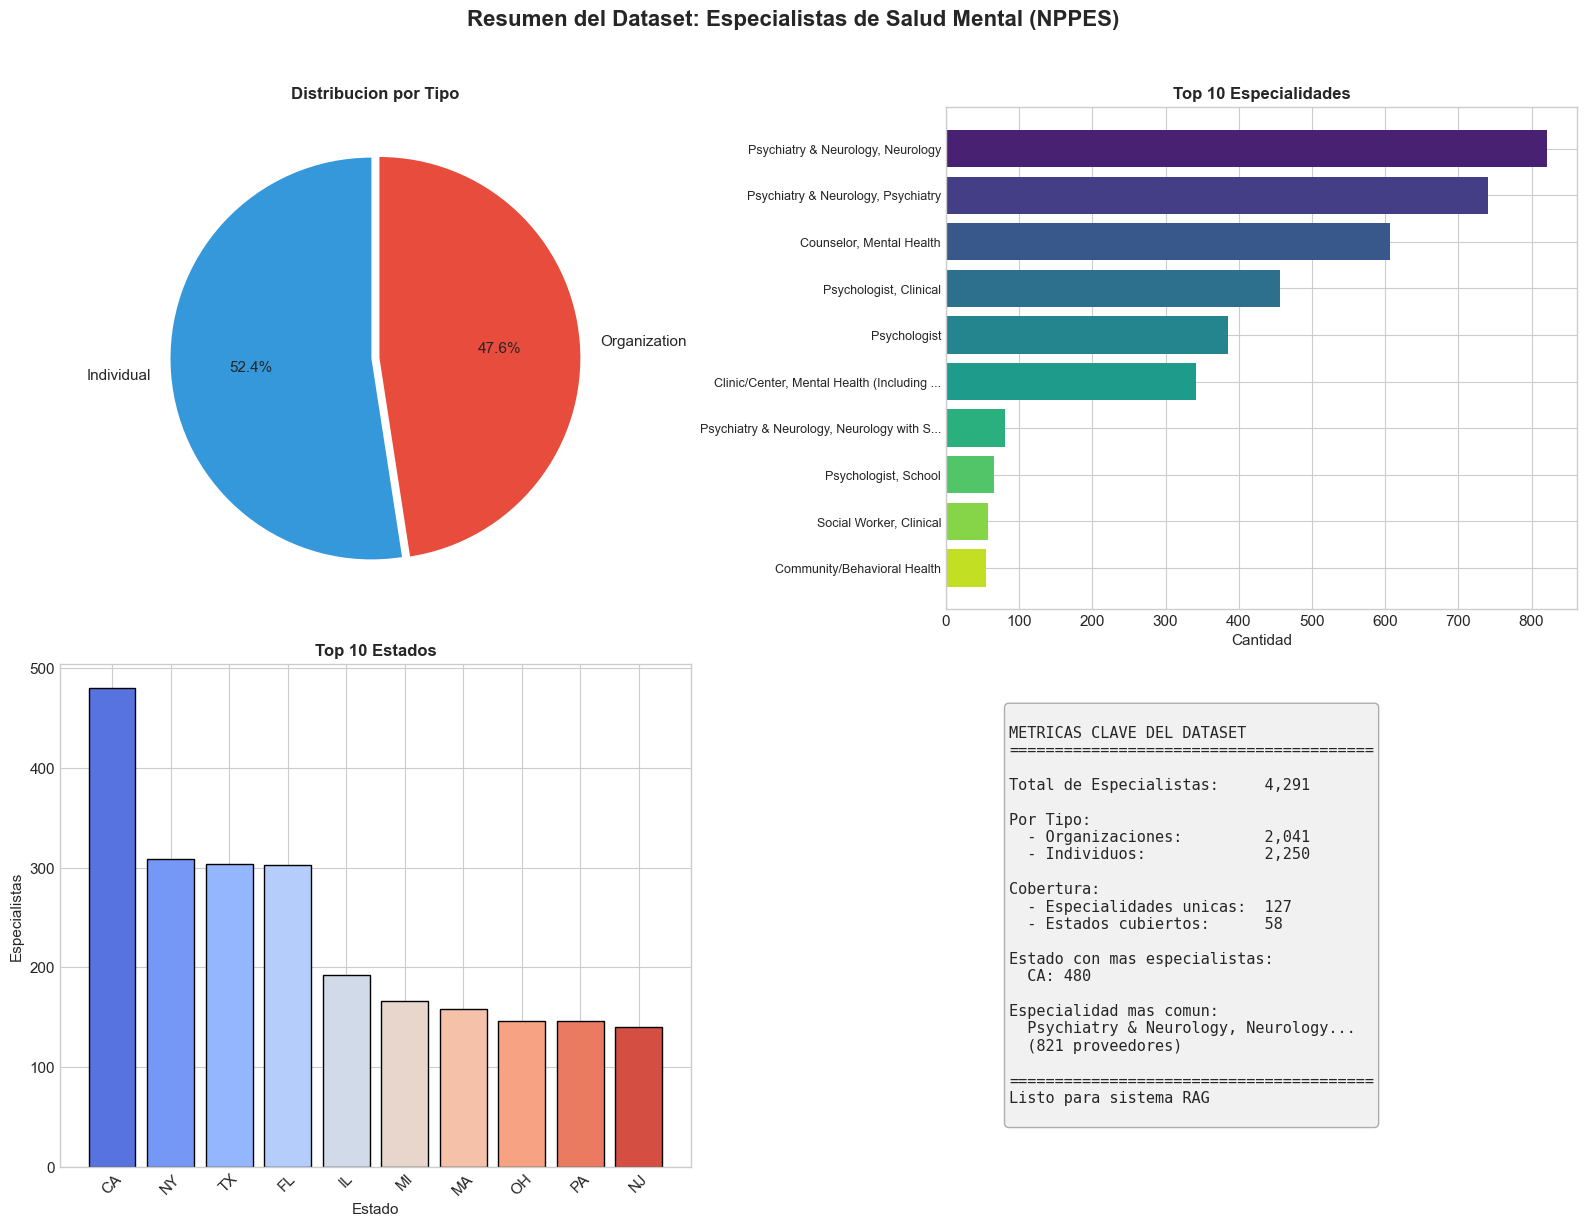

In [30]:
# Estadisticas finales
print("ESTADISTICAS FINALES")
print("=" * 70)
print(f"Total especialistas: {len(df):,}")
print(f"Especialidades unicas: {df['primary_taxonomy'].nunique():,}")
print(f"Estados cubiertos: {df['state'].nunique()}")
print(f"Organizaciones: {(df['provider_type'] == 'Organization').sum():,}")
print(f"Individuos: {(df['provider_type'] == 'Individual').sum():,}")
print("\n" + "=" * 70)
print("Datos listos para crear el sistema RAG.")

# Dashboard resumen
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Resumen del Dataset: Especialistas de Salud Mental (NPPES)', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Tipos de proveedor (pie)
ax1 = axes[0, 0]
provider_types.plot(kind='pie', ax=ax1, autopct='%1.1f%%', colors=['#3498db', '#e74c3c'],
                    startangle=90, explode=[0.02, 0.02])
ax1.set_title('Distribucion por Tipo', fontsize=12, fontweight='bold')
ax1.set_ylabel('')

# 2. Top 10 especialidades (barh)
ax2 = axes[0, 1]
top_10_specs = df['primary_taxonomy'].value_counts().head(10)
colors_specs = sns.color_palette("viridis", len(top_10_specs))
ax2.barh(range(len(top_10_specs)), top_10_specs.values, color=colors_specs)
ax2.set_yticks(range(len(top_10_specs)))
ax2.set_yticklabels([s[:40] + '...' if len(s) > 40 else s for s in top_10_specs.index], fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Top 10 Especialidades', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cantidad')

# 3. Top 10 estados (bar)
ax3 = axes[1, 0]
top_10_states = df['state'].value_counts().head(10)
colors_states = sns.color_palette("coolwarm", len(top_10_states))
ax3.bar(top_10_states.index, top_10_states.values, color=colors_states, edgecolor='black')
ax3.set_title('Top 10 Estados', fontsize=12, fontweight='bold')
ax3.set_xlabel('Estado')
ax3.set_ylabel('Especialistas')
ax3.tick_params(axis='x', rotation=45)

# 4. Metricas clave (texto)
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = f"""
METRICAS CLAVE DEL DATASET
{'='*40}

Total de Especialistas:     {len(df):,}

Por Tipo:
  - Organizaciones:         {(df['provider_type'] == 'Organization').sum():,}
  - Individuos:             {(df['provider_type'] == 'Individual').sum():,}

Cobertura:
  - Especialidades unicas:  {df['primary_taxonomy'].nunique():,}
  - Estados cubiertos:      {df['state'].nunique()}

Estado con mas especialistas:
  {top_states.index[0]}: {top_states.values[0]:,}

Especialidad mas comun:
  {top_specialties.index[0][:35]}...
  ({top_specialties.values[0]:,} proveedores)

{'='*40}
Listo para sistema RAG
"""
ax4.text(0.1, 0.5, metrics_text, transform=ax4.transAxes, fontsize=11,
         verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))

plt.tight_layout()
plt.show()